# Lab 05 — Perceptron / logistic regression จากศูนย์ด้วย numpy
### A single perceptron: forward, loss, gradient descent, vectorization

**กลุ่ม:** B perceptron · **อ่านคู่กับสไลด์หน้า:** 13-31, 40-56 · **เวลาโดยประมาณ:** 120 นาที · **Dataset:** nnlab.data.load_lung_cancer_toy, nnlab.data.load_blobs

**ควรทำมาก่อน:** Lab 01 (shape, broadcasting, `@` และ vectorization)

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. เขียน forward propagation ของ perceptron หนึ่งตัว $z = w^T x + b$, $a = \sigma(z)$ และอธิบายได้ว่า $\hat{y}$ คือ $P(y=1 \mid x)$
2. คำนวณ loss $\mathcal{L}$ ของ 1 sample และ cost $\mathcal{J}$ ของทั้ง training set ด้วย binary cross-entropy และอธิบายได้ว่าทำไมใช้ $-\log$
3. อธิบาย gradient descent และพิสูจน์ด้วยการ nudge ว่า $dz = a - y$, $dw = \frac{1}{m} X dz^T$, $db = \frac{1}{m}\sum dz$
4. เขียน training loop แบบ naive loop กับแบบ vectorized ให้ผลเท่ากันทุกหลัก และวัดว่าเร็วต่างกันกี่เท่า
5. เทรน perceptron บนข้อมูล 2 มิติ วาด cost curve และ decision boundary และตีความ $e^{w_j}$ เป็น odds ratio

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed

rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์ในบทนี้
| สัญลักษณ์ | ความหมาย | shape ใน numpy (convention สไลด์) |
|---|---|---|
| $\mathbf{x}^{(i)}$ | feature vector ของ sample ที่ $i$ | `(n_x, 1)` |
| $X$ | training data ทุก sample เรียงเป็น**คอลัมน์** (p.14) | `(n_x, m)` |
| $y^{(i)}$, $Y$ | label 0/1 ของ sample $i$ / ของทุก sample | scalar / `(1, m)` |
| $m$ | จำนวน sample | `X.shape[1]` |
| $n_x$ | จำนวน feature | `X.shape[0]` |
| $w$ | weight หนึ่งตัวต่อหนึ่ง feature | `(n_x, 1)` |
| $b$ | bias | scalar |
| $z$ | linear combination $w^T x + b$ (logit) | `(1, m)` |
| $a = \hat{y}$ | output $\sigma(z) = P(y = 1 \mid x)$ | `(1, m)` |
| $\mathcal{L}(\hat{y}, y)$ | loss ของ **1** sample (p.17) | scalar |
| $\mathcal{J}(w, b)$ | cost = ค่าเฉลี่ยของ loss ทุก sample (p.18) | scalar |
| $\alpha$ | learning rate (p.20) | scalar |

> สไลด์ p.15 และ p.31 เขียน $w \in \mathbb{R}^{1 \times n_x}$ แต่สูตร $w^T \cdot x$ ใช้ได้ก็ต่อเมื่อ $w$ เป็น $n_x \times 1$ — notebook นี้ (และ `nnlab`) จึงตรึง `w.shape == (n_x, 1)` ตลอด

## ขั้นที่ 1 · training sample กับ training data (สไลด์ p.14)
- **training sample** คือคู่ $(\mathbf{x}, y)$ หนึ่งคู่: feature vector $\mathbf{x} \in \mathbb{R}^{n_x}$ กับ label $y \in \{0, 1\}$
- **training data** คือ sample $m$ คู่ $(\mathbf{x}^{(1)}, y^{(1)}), \dots, (\mathbf{x}^{(m)}, y^{(m)})$

เราใช้ตารางเล็กในสไลด์ p.40: $x_1$ = จำนวนครั้งที่สูบบุหรี่ต่อสัปดาห์, $x_2$ = เจ็บหน้าอก (1/0), $y$ = เป็นมะเร็งปอด (1/0) — มี $m = 3$ sample, $n_x = 2$ feature
`load_lung_cancer_toy` คืนข้อมูลแบบที่ library ทั่วไป (pandas, scikit-learn) ใช้: **sample เป็นแถว** `X_rows (3, 2)` และ `y (3,)`

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

In [2]:
from nnlab.data import load_lung_cancer_toy
from nnlab.conventions import describe

X_rows, y = load_lung_cancer_toy()       # X_rows: (m, n_x) = (3, 2) , y: (m,) = (3,)
print("X_rows =\n", X_rows)
print("y      =", y)
print(describe(X_rows, "lib"))
for i in range(len(y)):
    print(f"training sample {i+1}: x = {X_rows[i]}, y = {y[i]}")

X_rows =
 [[3. 1.]
 [5. 0.]
 [2. 1.]]
y      = [0 1 0]
shape (3, 2) → m=3 samples, n_x=2 features (sample เป็นแถว)
training sample 1: x = [3. 1.], y = 0
training sample 2: x = [5. 0.], y = 1
training sample 3: x = [2. 1.], y = 0


### สะพานสู่ convention ของสไลด์
สไลด์ p.14 วาง sample เป็น **คอลัมน์**: $X \in \mathbb{R}^{n_x \times m}$ และ $Y \in \mathbb{R}^{1 \times m}$
ทำไมต้องหมุน: สูตรของ sample เดียว $z = w^T \mathbf{x} + b$ จะขยายเป็นสูตรของทุก sample $Z = w^T X + b$ ได้**โดยไม่ต้องเขียนใหม่** เมื่อแต่ละ $\mathbf{x}^{(i)}$ เป็นคอลัมน์ของ $X$
การแปลงใช้แค่ `.T` (transpose) กับ `reshape(1, -1)` — ข้อมูลไม่เปลี่ยน แค่หมุนตาราง จากนี้ไปทั้ง notebook ใช้ convention สไลด์ จนกว่าจะบอกเปลี่ยน

In [3]:
X = X_rows.T                             # X: (n_x, m) = (2, 3)  sample เป็นคอลัมน์
Y = y.reshape(1, -1).astype(float)       # Y: (1, m) = (1, 3)
n_x, m = X.shape
print("X =\n", X)
print(describe(X, "deck"))
print("Y =", Y, "shape", Y.shape)
print(f"n_x = {n_x} feature, m = {m} sample")
print("x^(1) = X[:, [0]] =\n", X[:, [0]], " shape", X[:, [0]].shape, " ← ใส่ [0] ใน list เพื่อคง 2 มิติ (n_x, 1)")

X =
 [[3. 5. 2.]
 [1. 0. 1.]]
shape (2, 3) → n_x=2 features, m=3 samples (sample เป็นคอลัมน์)
Y = [[0. 1. 0.]] shape (1, 3)
n_x = 2 feature, m = 3 sample
x^(1) = X[:, [0]] =
 [[3.]
 [1.]]  shape (2, 1)  ← ใส่ [0] ใน list เพื่อคง 2 มิติ (n_x, 1)


> **Convention ที่ใช้ในส่วนนี้: สไลด์ (deck)** — `X` มี shape `(n_x, m)` sample เป็น**คอลัมน์**, `Y` มี shape `(1, m)`, `w` มี shape `(n_x, 1)` และ `Z = w.T @ X + b`

## ขั้นที่ 2 · perceptron กับ sample เดียว (สไลด์ p.15-16)
perceptron คือหน่วยเล็กที่สุดของ neural network ทำงาน 2 จังหวะ
1. **linear combination**: $z = w^T \mathbf{x} + b = w_1 x_1 + w_2 x_2 + b$ — ถ่วงน้ำหนักแต่ละ feature แล้วบวก bias
2. **activation**: $a = \hat{y} = g(z) = \sigma(z) = \dfrac{1}{1 + e^{-z}}$ — บีบให้อยู่ใน $(0, 1)$

ทำไมต้อง sigmoid: เราอยากตีความ $\hat{y}$ เป็น **ความน่าจะเป็น** $P(y = 1 \mid \mathbf{x})$ ซึ่งต้องอยู่ระหว่าง 0 กับ 1
สไลด์ p.16: $z \gg 0 \Rightarrow \sigma(z) \to 1$ และ $z \ll 0 \Rightarrow \sigma(z) \to 0$; ที่ $z = 0$ ได้ $\sigma(0) = 0.5$ พอดี

ลองกับ sample แรก $\mathbf{x}^{(1)} = (3, 1)^T$ ด้วย $w = (0.1, 0.2)^T$, $b = 0.3$ (ค่าเดียวกับ $\theta_1, \theta_2, \theta_0$ ในสไลด์ p.42)
คาดว่าจะเห็น $z^{(1)} = 0.1 \times 3 + 0.2 \times 1 + 0.3 = 0.8$ และ $a^{(1)} = \sigma(0.8) \approx 0.69$

w.T = [[0.1 0.2]] shape (1, 2)
z^(1) = w1*x1 + w2*x2 + b = 0.1*3 + 0.2*1 + 0.3 = 0.80
a^(1) = sigmoid(0.80) = 0.6900  → โมเดลบอก P(y=1 | x^(1)) ≈ 69.0% แต่ label จริง y^(1) = 0


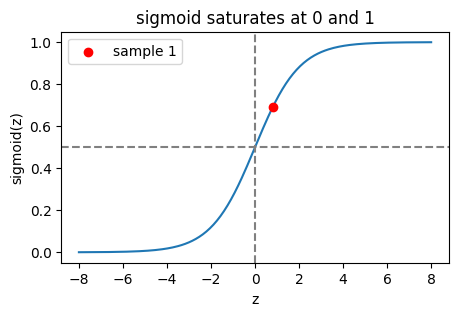

In [4]:
def sigmoid(z):
    """g(z) = 1 / (1 + e^{-z})  (สไลด์ p.16) — ใช้ได้ทั้ง scalar และ array"""
    return 1.0 / (1.0 + np.exp(-z))

w = np.array([[0.1], [0.2]])            # w: (n_x, 1) = (2, 1)
b = 0.3                                  # b: scalar

x1 = X[:, [0]]                           # x^(1): (n_x, 1) = (2, 1)
z1 = w.T @ x1 + b                        # (1, 2) @ (2, 1) → (1, 1)
a1 = sigmoid(z1)                         # (1, 1)
print("w.T =", w.T, "shape", w.T.shape)
print(f"z^(1) = w1*x1 + w2*x2 + b = {w[0,0]}*{x1[0,0]:g} + {w[1,0]}*{x1[1,0]:g} + {b} = {z1[0,0]:.2f}")
print(f"a^(1) = sigmoid({z1[0,0]:.2f}) = {a1[0,0]:.4f}  → โมเดลบอก P(y=1 | x^(1)) ≈ {a1[0,0]:.1%} แต่ label จริง y^(1) = {int(Y[0,0])}")

zs = np.linspace(-8, 8, 200)
plt.figure(figsize=(5, 3))
plt.plot(zs, sigmoid(zs)); plt.axhline(0.5, ls="--", c="gray"); plt.axvline(0, ls="--", c="gray")
plt.scatter(z1, a1, c="red", zorder=3, label="sample 1")
plt.xlabel("z"); plt.ylabel("sigmoid(z)"); plt.title("sigmoid saturates at 0 and 1"); plt.legend(); plt.show()

## ขั้นที่ 3 · ทุก sample พร้อมกันในคำสั่งเดียว (สไลด์ p.28, 40-52)
ถ้ามี sample 3 ตัวก็เขียน `w.T @ x` 3 ครั้งได้ แต่ถ้ามีล้านตัวล่ะ
สไลด์ p.43-49 สาธิตว่า $\theta^T X$ คือการทำ dot product กับ **ทุกคอลัมน์** ของ $X$ ในทีเดียว
เริ่มจากคำนวณ "ด้วยมือ" ทีละ sample ก่อน ให้เห็นว่าตัวเลข 0.5, 0.5, 0.4 ในสไลด์ p.46 มาจากไหน

In [5]:
theta = w                                # สไลด์ p.42 เรียก w1, w2 ว่า θ1, θ2 และเรียก b ว่า θ0
for i in range(m):
    x_i = X[:, i]                        # (n_x,) feature ของ sample i
    dot = theta[0, 0] * x_i[0] + theta[1, 0] * x_i[1]
    print(f"sample {i+1}: θᵀx^({i+1}) = {theta[0,0]}×{x_i[0]:g} + {theta[1,0]}×{x_i[1]:g} = {dot:.1f}")

sample 1: θᵀx^(1) = 0.1×3 + 0.2×1 = 0.5
sample 2: θᵀx^(2) = 0.1×5 + 0.2×0 = 0.5
sample 3: θᵀx^(3) = 0.1×2 + 0.2×1 = 0.4


ทีนี้ให้ numpy ทำทั้งสามคอลัมน์พร้อมกัน: `w.T @ X` มี shape `(1, 2) @ (2, 3) → (1, 3)` — ตัวเลขต้องตรงกับที่คำนวณด้วยมือ
บวก $b$ ที่เป็น scalar ตัวเดียว numpy จะ **broadcast** ให้ทุกคอลัมน์ (สไลด์ p.48 วาด 0.3 ซ้ำ 3 ครั้ง) ได้ $Z$ → ผ่าน sigmoid ได้ $A$ → error $\varepsilon = Y - A$ (สไลด์ p.52)

In [6]:
thetaTX = w.T @ X                        # (1, n_x) @ (n_x, m) → (1, m) = (1, 3)
Z = thetaTX + b                          # broadcast b ไปทุกคอลัมน์ → Z: (1, m)
A = sigmoid(Z)                           # A: (1, m)
eps = Y - A                              # ε = Y − A: (1, m)  (สไลด์ p.52)

print("θᵀX       =", thetaTX, thetaTX.shape, " ← ตรงกับที่คำนวณด้วยมือ (สไลด์ p.46-47)")
print("Z = θᵀX+b =", Z)
print("A = σ(Z)  =", A)
print("ε = Y − A =", eps)
assert np.allclose(thetaTX, [[0.5, 0.5, 0.4]])
assert np.isclose(Z[0, 0], z1[0, 0]) and np.isclose(A[0, 0], a1[0, 0]), "คอลัมน์แรกต้องเท่ากับ sample เดียวในขั้นที่ 2"

θᵀX       = [[0.5 0.5 0.4]] (1, 3)  ← ตรงกับที่คำนวณด้วยมือ (สไลด์ p.46-47)
Z = θᵀX+b = [[0.8 0.8 0.7]]
A = σ(Z)  = [[0.69   0.69   0.6682]]
ε = Y − A = [[-0.69    0.31   -0.6682]]


> **หมายเหตุเรื่องลำดับ:** diagram ในสไลด์ p.49 ให้ข้อมูลไหลจากซ้ายไปขวา และเขียน sample ที่ 1 ไว้**ขวาสุด** จึงอ่านได้เป็น [0.7, 0.8, 0.8]
> ส่วนโค้ดเรียง sample ที่ 1 ไว้คอลัมน์แรก (ซ้ายสุด) จึงพิมพ์ [0.8, 0.8, 0.7] — ตัวเลขชุดเดียวกัน ต่างแค่ทิศทางการอ่าน
> **หมายเหตุ errata:** สไลด์ฉบับก่อน ก.ย. 2026 (p.52) เขียน $\hat{y}$ = [0.49, 0.45, 0.45] ค่าที่ถูกคือที่ cell คำนวณ $\sigma(z)$ = [0.690, 0.690, 0.668]
> สังเกตง่ายๆ ว่า $z > 0$ ทุกตัว ดังนั้น $\sigma(z)$ ต้องมากกว่า 0.5 เสมอ (ค่า $\varepsilon$ และค่า $\ln$ ใน p.63 ของฉบับนั้นจึงต่างไปด้วย — คำนวณสดใน lab06)

## ขั้นที่ 4 · loss ของ 1 sample และ cost ของทั้งชุด (สไลด์ p.17-18)
เรามี $\hat{y}$ กับ $y$ แล้ว ต้องมีตัวเลขบอกว่า "ผิดมากแค่ไหน" — **loss function** $\mathcal{L}(\hat{y}, y)$ ของ sample เดียว
$$\mathcal{L}(\hat{y}, y) = -\big(y \log \hat{y} + (1 - y) \log(1 - \hat{y})\big) \qquad \text{(binary cross-entropy)}$$
ดูทีละกรณีจะเข้าใจง่ายกว่า เพราะ $y$ เป็นได้แค่ 0 หรือ 1 จึงเหลือพจน์เดียวเสมอ
- $y = 1$: เหลือ $-\log \hat{y}$ — ถ้า $\hat{y} \to 1$ loss → 0 (ทายถูก) ถ้า $\hat{y} \to 0$ loss → $\infty$ (ทายผิดแบบมั่นใจ โดนลงโทษหนัก)
- $y = 0$: เหลือ $-\log(1 - \hat{y})$ — กลับด้านกัน

**cost function** $\mathcal{J}(w, b) = \dfrac{1}{m}\sum_{i=1}^{m} \mathcal{L}(\hat{y}^{(i)}, y^{(i)})$ คือค่าเฉลี่ยของ loss ทั้ง training set (สไลด์ p.18)
เป้าหมายของการเทรนคือหา $w, b$ ที่ทำให้ $\mathcal{J}$ ต่ำสุด — cell ถัดไปคำนวณ loss ทั้ง 3 sample และ cost ของ $\theta$ ชุดสาธิต

In [7]:
def bce_loss(a, y):
    """loss ต่อ sample ℒ(a, y) = −(y log a + (1−y) log(1−a))  — a, y shape เท่ากัน คืน shape เดิม"""
    return -(y * np.log(a) + (1 - y) * np.log(1 - a))

def cost(A, Y):
    """cost 𝒥 = ค่าเฉลี่ยของ loss ทุก sample  — A, Y: (1, m) คืน scalar"""
    return np.mean(bce_loss(A, Y))

L = bce_loss(A, Y)                                       # L: (1, m)
for i in range(m):
    if Y[0, i] == 1:
        case = f"y=1 → −log(a)   = −log({A[0,i]:.4f})"
    else:
        case = f"y=0 → −log(1−a) = −log({1-A[0,i]:.4f})"
    print(f"sample {i+1}: {case} = {L[0,i]:.4f}")
J = cost(A, Y)
print(f"\ncost 𝒥(w, b) = mean(loss) = {J:.4f}   ← ตัวเลขเดียวที่สรุปว่า θ ชุดนี้แย่แค่ไหน")
assert np.isclose(J, L.mean())

sample 1: y=0 → −log(1−a) = −log(0.3100) = 1.1711
sample 2: y=1 → −log(a)   = −log(0.6900) = 0.3711
sample 3: y=0 → −log(1−a) = −log(0.3318) = 1.1032

cost 𝒥(w, b) = mean(loss) = 0.8818   ← ตัวเลขเดียวที่สรุปว่า θ ชุดนี้แย่แค่ไหน


วาดสองกรณีเทียบกัน: แกนนอนคือ $\hat{y}$ ที่โมเดลทาย แกนตั้งคือ loss
สังเกตว่าโค้ง $-\log \hat{y}$ พุ่งขึ้นไม่มีที่สิ้นสุดเมื่อ $\hat{y} \to 0$ — นี่คือเหตุผลที่โมเดลจะถูก "ผลัก" แรงมากเมื่อทายผิดแบบมั่นใจ
จุดคือ loss ของ 3 sample จากตารางมะเร็งปอด: sample 2 ($y = 1$) อยู่บนโค้งสีน้ำเงิน อีกสองตัว ($y = 0$) อยู่บนโค้งสีส้ม

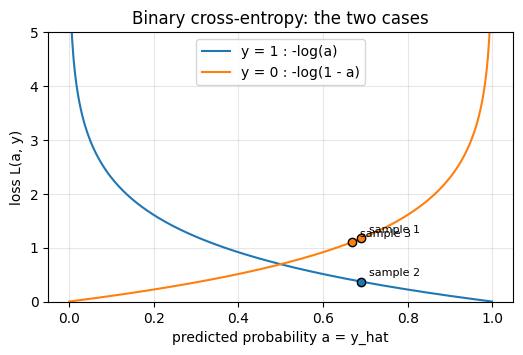

In [8]:
a_grid = np.linspace(0.001, 0.999, 300)
plt.figure(figsize=(6, 3.5))
plt.plot(a_grid, -np.log(a_grid), label="y = 1 : -log(a)")
plt.plot(a_grid, -np.log(1 - a_grid), label="y = 0 : -log(1 - a)")
for i in range(m):
    plt.scatter(A[0, i], L[0, i], c="C0" if Y[0, i] == 1 else "C1", edgecolor="k", zorder=3)
    plt.annotate(f"sample {i+1}", (A[0, i], L[0, i]), textcoords="offset points", xytext=(6, 4), fontsize=8)
plt.ylim(0, 5); plt.xlabel("predicted probability a = y_hat"); plt.ylabel("loss L(a, y)")
plt.title("Binary cross-entropy: the two cases"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## ขั้นที่ 5 · gradient descent: เดินลงเขาทีละก้าว (สไลด์ p.19-21)
$\mathcal{J}(w, b)$ เป็นพื้นผิวรูปชามในสไลด์ p.19 เรายืนอยู่ที่จุดใดจุดหนึ่งบนชาม อยากเดินลงไปก้นชาม
**gradient descent** ทำซ้ำกติกาเดียว (สไลด์ p.20)
$$w := w - \alpha \frac{d\mathcal{J}}{dw}$$
- อนุพันธ์ $\frac{d\mathcal{J}}{dw}$ คือ "ความชัน" ณ จุดที่ยืน: ชันบวก (อยู่ขวาของก้นชาม) → ลบออก $w$ ลดลง; ชันลบ (อยู่ซ้าย) → $w$ เพิ่มขึ้น — เดินเข้าหาก้นชามเสมอ
- $\alpha$ คือ **learning rate** ก้าวยาวแค่ไหน: เล็กเกินไปช้า ใหญ่เกินไปกระโดดข้ามก้นชามแล้วไต่กลับขึ้นไปเรื่อยๆ (overshoot)

ลองกับตัวอย่าง 1 มิติที่รู้คำตอบ: $\mathcal{J}(w) = (w - 3)^2$ ต่ำสุดที่ $w = 3$ อนุพันธ์ $\frac{d\mathcal{J}}{dw} = 2(w - 3)$ เริ่มจาก $w_0 = 0$
คาดว่า $\alpha = 0.1$ จะค่อยๆ เข้าใกล้ 3 ส่วน $\alpha = 1.1$ จะแกว่งห่างออกไปทุกก้าว

α = 0.1 : [0.    0.6   1.08  1.464 1.771 2.017 2.214 2.371 2.497 2.597 2.678 2.742
 2.794 2.835 2.868 2.894] → เข้าใกล้ 3 ทีละก้าว
α = 1.1 : [ 0.     6.6   -1.32   8.184 -3.221 10.465 -5.958] → กระโดดข้าม 3 แล้วห่างออกไปเรื่อยๆ (overshoot)


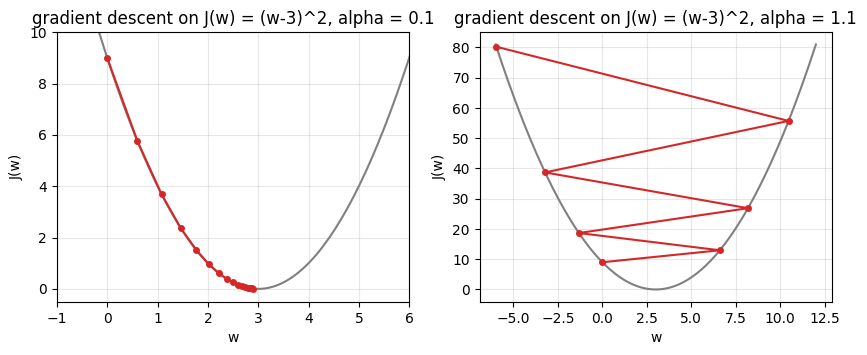

In [9]:
J_fn  = lambda w_: (w_ - 3) ** 2         # cost 1 มิติ ต่ำสุดที่ w = 3
dJ_fn = lambda w_: 2 * (w_ - 3)          # อนุพันธ์ = ความชัน

def gradient_descent_1d(w0, alpha, steps):
    path = [w0]
    w_ = w0
    for _ in range(steps):
        w_ = w_ - alpha * dJ_fn(w_)      # กติกาเดียวของ gradient descent (สไลด์ p.20)
        path.append(w_)
    return np.array(path)

path_ok  = gradient_descent_1d(0.0, alpha=0.1, steps=15)
path_bad = gradient_descent_1d(0.0, alpha=1.1, steps=6)
print("α = 0.1 :", np.round(path_ok, 3), "→ เข้าใกล้ 3 ทีละก้าว")
print("α = 1.1 :", np.round(path_bad, 3), "→ กระโดดข้าม 3 แล้วห่างออกไปเรื่อยๆ (overshoot)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
w_grid = np.linspace(-6, 12, 300)
for ax, path, alpha in zip(axes, [path_ok, path_bad], [0.1, 1.1]):
    ax.plot(w_grid, J_fn(w_grid), c="gray")
    ax.plot(path, J_fn(path), "o-", c="C3", ms=4)
    ax.set_title(f"gradient descent on J(w) = (w-3)^2, alpha = {alpha}"); ax.set_xlabel("w"); ax.set_ylabel("J(w)"); ax.grid(alpha=0.3)
axes[0].set_xlim(-1, 6); axes[0].set_ylim(-0.5, 10)
plt.show()

## ขั้นที่ 6 · backward propagation ของ perceptron (สไลด์ p.25-26)
จะใช้กติกาในขั้นที่ 5 ได้ต้องรู้ $\frac{\partial \mathcal{J}}{\partial w}$ และ $\frac{\partial \mathcal{J}}{\partial b}$ ก่อน
สไลด์ p.26 ใช้ chain rule ไล่ย้อน computational graph $(x, w, b) \to z \to a \to \mathcal{L}$ แล้วได้ผลลัพธ์ที่สวยมาก
$$dz \equiv \frac{\partial \mathcal{L}}{\partial z} = \frac{\partial \mathcal{L}}{\partial a}\cdot\frac{da}{dz} = \Big(-\frac{y}{a} + \frac{1-y}{1-a}\Big)\cdot a(1-a) = a - y$$
คือ "ผลต่างระหว่างที่ทายกับที่ควรเป็น" เท่านั้นเอง
ก่อนเชื่อสูตร เราตรวจด้วยวิธีสไลด์ p.23: **nudge** ค่า $z$ นิดหนึ่ง ($\Delta z = 0.001$) แล้วดูว่า $\mathcal{L}$ เปลี่ยนไปเท่าไร อัตราส่วน $\Delta\mathcal{L} / \Delta z$ ต้องใกล้ $a - y$ ทุก sample

In [10]:
def nudge(f, x, dx=1e-3):
    """อนุพันธ์เชิงตัวเลขแบบสไลด์ p.23: (f(x + dx) − f(x)) / dx"""
    return (f(x + dx) - f(x)) / dx

for i in range(m):
    z_i, y_i, a_i = Z[0, i], Y[0, i], A[0, i]
    L_of_z = lambda z_: bce_loss(sigmoid(z_), y_i)      # loss ของ sample i เมื่อมองเป็นฟังก์ชันของ z
    print(f"sample {i+1}: nudge ΔL/Δz = {nudge(L_of_z, z_i):.4f}   สูตร a − y = {a_i - y_i:.4f}")

dz = A - Y                                # dz: (1, m)  ← ทุก sample พร้อมกันในบรรทัดเดียว
print("\ndz = A − Y =", dz, " (= −ε จากขั้นที่ 3)")

sample 1: nudge ΔL/Δz = 0.6901   สูตร a − y = 0.6900
sample 2: nudge ΔL/Δz = -0.3099   สูตร a − y = -0.3100
sample 3: nudge ΔL/Δz = 0.6683   สูตร a − y = 0.6682

dz = A − Y = [[ 0.69   -0.31    0.6682]]  (= −ε จากขั้นที่ 3)


### จาก $dz$ ไปถึง $dw$, $db$ (สไลด์ p.30-31)
$z = w_1 x_1 + w_2 x_2 + b$ ดังนั้น $\frac{\partial z}{\partial w_j} = x_j$ และ $\frac{\partial z}{\partial b} = 1$ — chain rule ต่ออีกขั้นได้ $dw_j^{(i)} = x_j^{(i)}\, dz^{(i)}$ และ $db^{(i)} = dz^{(i)}$
cost คือค่าเฉลี่ยของ loss ทุก sample อนุพันธ์ของ cost จึงเป็นค่าเฉลี่ยของอนุพันธ์แต่ละ sample ซึ่ง matrix multiplication ทำให้ในบรรทัดเดียว
$$dw = \frac{1}{m} X\, dz^T \quad (n_x \times m)(m \times 1) \to (n_x \times 1), \qquad db = \frac{1}{m}\sum_{i} dz^{(i)}$$
ตรวจอีกครั้งด้วยการ nudge $w_1, w_2, b$ ทีละตัวแล้วดู $\Delta\mathcal{J}/\Delta\theta$ — คราวนี้ใช้ dx เล็กลงและแบบ central `(f(x+dx) − f(x−dx)) / 2dx` เพื่อให้แม่นพอจะ `assert`

In [11]:
dw = (X @ dz.T) / m                       # (n_x, m) @ (m, 1) → dw: (n_x, 1)
db = np.sum(dz) / m                       # scalar
print("dw =", dw.ravel(), "shape", dw.shape, "| db =", round(db, 4))

def J_of(w_, b_):                         # cost เมื่อมองเป็นฟังก์ชันของ (w, b) โดย X, Y คงที่
    return cost(sigmoid(w_.T @ X + b_), Y)

h = 1e-5
num_dw = np.zeros_like(w)                 # (n_x, 1)
for j in range(n_x):
    e = np.zeros_like(w); e[j, 0] = h                     # nudge เฉพาะ w_j
    num_dw[j, 0] = (J_of(w + e, b) - J_of(w - e, b)) / (2 * h)
num_db = (J_of(w, b + h) - J_of(w, b - h)) / (2 * h)
print("numerical dw =", num_dw.ravel(), "| numerical db =", round(num_db, 4))
assert np.allclose(dw, num_dw, atol=1e-6) and np.isclose(db, num_db, atol=1e-6)
print("สูตร backward ตรงกับการ nudge ✓")

dw = [0.6187 0.4527] shape (2, 1) | db = 0.3494
numerical dw = [0.6187 0.4527] | numerical db = 0.3494
สูตร backward ตรงกับการ nudge ✓


## ขั้นที่ 7 · naive loop กับ vectorized (สไลด์ p.29-31)
รวมทุกอย่างเป็น **หนึ่ง epoch** = forward ทุก sample → คำนวณ cost → backward → อัปเดต $w, b$ หนึ่งครั้ง
- สไลด์ p.29 เขียนแบบ "loop and loop and loop": วน sample $i$ แล้ววน feature $j$ — เห็นทุกขั้นชัด แต่ช้า
- สไลด์ p.30-31 เขียนแบบ vectorized: 6 บรรทัด ไม่มี loop เหนือ sample เลย

สองฟังก์ชันข้างล่างรับ input เดียวกัน คืน `(w_ใหม่, b_ใหม่, cost)` เหมือนกัน — ต้องได้ตัวเลข **เท่ากันทุกหลัก** และ cost ต้องเท่ากับ $\mathcal{J}$ ในขั้นที่ 4

In [12]:
def naive_epoch(w, b, X, Y, lr):
    """หนึ่ง epoch ตามสไลด์ p.29 — วน i (sample) และ j (feature) ด้วยมือ"""
    n_x, m = X.shape
    J, db = 0.0, 0.0
    dw = np.zeros((n_x, 1))                             # dw: (n_x, 1)
    for i in range(m):
        z_i = b
        for j in range(n_x):
            z_i += w[j, 0] * X[j, i]                    # z^(i) = Σ_j w_j x_j^(i) + b
        a_i = 1.0 / (1.0 + np.exp(-z_i))
        J += -(Y[0, i] * np.log(a_i) + (1 - Y[0, i]) * np.log(1 - a_i))
        dz_i = a_i - Y[0, i]
        for j in range(n_x):
            dw[j, 0] += X[j, i] * dz_i                  # สะสม dw_j
        db += dz_i
    J, dw, db = J / m, dw / m, db / m
    return w - lr * dw, b - lr * db, J

def vectorized_epoch(w, b, X, Y, lr):
    """หนึ่ง epoch ตามสไลด์ p.30-31 — ไม่มี loop เหนือ sample"""
    m = X.shape[1]
    Z = w.T @ X + b                                     # Z : (1, m)
    A = sigmoid(Z)                                      # A : (1, m)
    J = cost(A, Y)                                      # scalar
    dz = A - Y                                          # dz: (1, m)
    dw = (X @ dz.T) / m                                 # dw: (n_x, 1)
    db = np.sum(dz) / m                                 # scalar
    return w - lr * dw, b - lr * db, J

w_n, b_n, J_n = naive_epoch(w, b, X, Y, lr=0.5)
w_v, b_v, J_v = vectorized_epoch(w, b, X, Y, lr=0.5)
print("naive      : w =", w_n.ravel(), "b =", round(b_n, 4), "J =", round(J_n, 4))
print("vectorized : w =", w_v.ravel(), "b =", round(b_v, 4), "J =", round(J_v, 4))
assert np.allclose(w_n, w_v) and np.isclose(b_n, b_v) and np.isclose(J_n, J_v) and np.isclose(J_v, J)
print("ผลเท่ากันทุกหลัก ✓  และ J เท่ากับ cost ในขั้นที่ 4 =", round(J, 4))

naive      : w = [-0.2094 -0.0264] b = 0.1253 J = 0.8818
vectorized : w = [-0.2094 -0.0264] b = 0.1253 J = 0.8818
ผลเท่ากันทุกหลัก ✓  และ J เท่ากับ cost ในขั้นที่ 4 = 0.8818


ผลเท่ากัน แล้วเวลาต่างกันแค่ไหน — ข้อมูล 3 แถวเล็กเกินจะวัด เราสร้าง blobs 2 มิติ $m = 2000$ แล้วจับเวลา **หนึ่ง epoch** ด้วย `%timeit` (รันซ้ำหลายรอบแล้วเฉลี่ย)
คาดว่า naive จะช้ากว่าเป็นร้อยเท่า และช่องว่างจะกว้างขึ้นเมื่อ $m$ หรือ $n_x$ โตขึ้น

In [13]:
from nnlab.data import load_blobs

X_big_rows, y_big = load_blobs(n=2000)                 # (2000, 2), (2000,) library convention
X_big, Y_big = X_big_rows.T, y_big.reshape(1, -1).astype(float)   # → deck: X_big (2, 2000), Y_big (1, 2000)
w0, b0 = np.zeros((2, 1)), 0.0                         # w0: (2, 1)
print("X_big", X_big.shape, "| Y_big", Y_big.shape)

t_naive = %timeit -o -q naive_epoch(w0, b0, X_big, Y_big, 0.1)
t_vec   = %timeit -o -q vectorized_epoch(w0, b0, X_big, Y_big, 0.1)
print(f"naive      : {t_naive.average*1e3:8.3f} ms ต่อ epoch")
print(f"vectorized : {t_vec.average*1e3:8.3f} ms ต่อ epoch")
print(f"→ vectorized เร็วกว่า ~{t_naive.average / t_vec.average:,.0f} เท่า ที่ m = 2000, n_x = 2")

X_big (2, 2000) | Y_big (1, 2000)


naive      :    4.583 ms ต่อ epoch
vectorized :    0.032 ms ต่อ epoch
→ vectorized เร็วกว่า ~142 เท่า ที่ m = 2000, n_x = 2


## ขั้นที่ 8 · เทรนจริงบนข้อมูล 2 มิติ (สไลด์ p.30 "for epoch = 1 to max_epoch")
ตอนนี้เหลือแค่วน epoch ซ้ำหลายรอบ เราใช้ blobs 200 จุด (2 กลุ่มที่เส้นตรงแบ่งได้) เพื่อวาดภาพได้
- เริ่ม $w = 0, b = 0$ ตามสไลด์ — ที่ $w = 0$ ทุก sample ได้ $a = 0.5$ ดังนั้น cost เริ่มที่ $-\log 0.5 = 0.6931$ **เสมอ** จำตัวเลขนี้ไว้ใช้ตรวจโค้ดตลอดคอร์ส
- $\alpha = 0.1$, 300 epoch, เก็บ cost ทุกรอบไว้วาด **cost curve** — ถ้าโค้ดถูก curve ต้องลดลงเรื่อยๆ

In [14]:
X_rows_blobs, y_blobs = load_blobs(n=200)                          # (200, 2), (200,) library convention
X_b, Y_b = X_rows_blobs.T, y_blobs.reshape(1, -1).astype(float)    # deck: X_b (2, 200), Y_b (1, 200)
print("X_b", X_b.shape, "| Y_b", Y_b.shape, "| สัดส่วน class 1 =", Y_b.mean())

lr, epochs = 0.1, 300
w_t, b_t = np.zeros((2, 1)), 0.0                                    # w_t: (2, 1)
costs = []
for epoch in range(epochs):
    w_t, b_t, J_epoch = vectorized_epoch(w_t, b_t, X_b, Y_b, lr)   # หนึ่ง epoch = หนึ่งก้าวของ gradient descent
    costs.append(J_epoch)
    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:3d}  cost {J_epoch:.4f}")
print("\nw หลังเทรน =", w_t.ravel(), "| b =", round(b_t, 4))
assert np.isclose(costs[0], np.log(2)), "epoch แรกที่ w = 0 ต้องได้ cost = log 2 = 0.6931"

X_b (2, 200) | Y_b (1, 200) | สัดส่วน class 1 = 0.5
epoch   0  cost 0.6931
epoch  50  cost 0.0065
epoch 100  cost 0.0035
epoch 150  cost 0.0024
epoch 200  cost 0.0018
epoch 250  cost 0.0015
epoch 299  cost 0.0013

w หลังเทรน = [-1.1862  0.0088] | b = -0.0217


วาด cost curve: แกนนอน epoch แกนตั้ง $\mathcal{J}$ — ลดชันช่วงแรกแล้วค่อยราบ นี่คือภาพที่เราจะดูทุกครั้งที่เทรนอะไรก็ตามในคอร์สนี้ (lab ถัดไปใช้ `nnlab.plotting.plot_history`)
จากนั้นวัด **accuracy**: ทาย 1 เมื่อ $a \ge 0.5$ (ซึ่งก็คือ $z \ge 0$) แล้วนับว่าตรง label กี่ส่วน

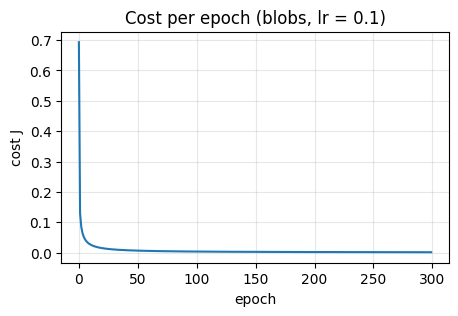

accuracy บน training set = 1.000  (200/200 ถูก)
cost ลดจาก 0.6931 เหลือ 0.0013


In [15]:
plt.figure(figsize=(5, 3))
plt.plot(costs); plt.xlabel("epoch"); plt.ylabel("cost J"); plt.title("Cost per epoch (blobs, lr = 0.1)"); plt.grid(alpha=0.3); plt.show()

A_b = sigmoid(w_t.T @ X_b + b_t)                       # A_b: (1, 200)
pred_b = (A_b >= 0.5).astype(int)                      # (1, 200) label 0/1
acc = np.mean(pred_b == Y_b)
print(f"accuracy บน training set = {acc:.3f}  ({int((pred_b == Y_b).sum())}/{Y_b.shape[1]} ถูก)")
print("cost ลดจาก", round(costs[0], 4), "เหลือ", round(costs[-1], 4))

### decision boundary คือเส้นตรง $w_1 x_1 + w_2 x_2 + b = 0$
โมเดลทาย 1 เมื่อ $a \ge 0.5 \iff z \ge 0$ ดังนั้นเส้นแบ่งคือจุดที่ $z = 0$ พอดี — ในข้อมูล 2 มิติคือ **เส้นตรง** $w_1 x_1 + w_2 x_2 + b = 0$
perceptron ตัวเดียวจึงแบ่งได้แค่ข้อมูลที่เส้นตรงแบ่งได้ (จะเห็นข้อจำกัดนี้กับ moons ใน lab07)
`plot_decision_boundary` ของ `nnlab` รับฟังก์ชันทำนายที่กิน grid แบบ library convention `(k, 2)` เราจึง transpose เป็น deck ก่อนคำนวณ แล้วคืน label เป็น vector `(k,)`
เส้นดำคือ $z = 0$ ที่วาดจากสมการตรงๆ — ต้องทับรอยต่อของพื้นสองสีพอดี

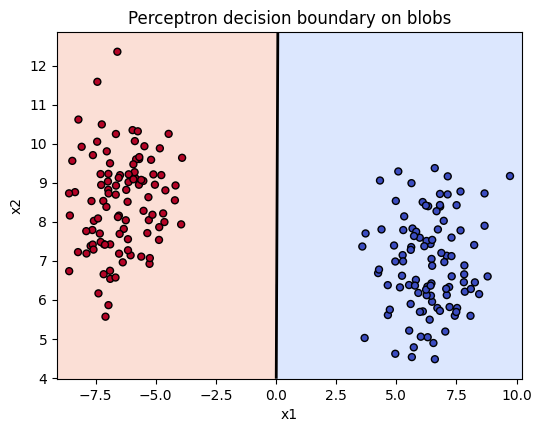

เส้นแบ่ง: -1.186·x1 + 0.009·x2 + -0.022 = 0
ทุกจุดที่ทายเป็น 1 มี z ≥ 0 และที่ทายเป็น 0 มี z < 0: True


In [16]:
from nnlab.plotting import plot_decision_boundary

predict_rows = lambda G: (sigmoid(w_t.T @ G.T + b_t) >= 0.5).astype(int).ravel()   # G: (k, 2) lib → G.T: (2, k) deck → (k,)

fig, ax = plt.subplots(figsize=(6, 4.5))
plot_decision_boundary(predict_rows, X_rows_blobs, y_blobs, ax=ax, title="Perceptron decision boundary on blobs")
xx, yy = np.meshgrid(np.linspace(*ax.get_xlim(), 200), np.linspace(*ax.get_ylim(), 200))
zz = w_t[0, 0] * xx + w_t[1, 0] * yy + b_t                # z = w1 x1 + w2 x2 + b บนทุกจุดของ grid
ax.contour(xx, yy, zz, levels=[0], colors="k", linewidths=2)   # เส้น z = 0
plt.show()
print(f"เส้นแบ่ง: {w_t[0,0]:.3f}·x1 + {w_t[1,0]:.3f}·x2 + {b_t:.3f} = 0")
z_on_data = w_t.T @ X_b + b_t                             # (1, 200)
print("ทุกจุดที่ทายเป็น 1 มี z ≥ 0 และที่ทายเป็น 0 มี z < 0:", bool(np.all((z_on_data >= 0) == (pred_b == 1))))

## ขั้นที่ 9 · logit, odds และการตีความ $w$ (สไลด์ p.53-56)
perceptron ที่ใช้ sigmoid ก็คือ **logistic regression** (สไลด์ p.33) ซึ่งนักสถิติมองอีกมุม
- **odds** ของเหตุการณ์ $y = 1$ คือ $\dfrac{P}{1 - P} = \dfrac{a}{1 - a}$ (สไลด์ p.55 นำ (1) หารด้วย (2))
- แทน $a = \sigma(z)$ แล้วจัดรูปได้ $\text{odds} = e^{z}$ ดังนั้น $\ln(\text{odds}) = z = w_1 x_1 + w_2 x_2 + b$ — เรียกว่า **logit** หรือ log-odds
- รูป logit หน้าตาเหมือน linear regression แต่ตัวแปรตามคือ log-odds ไม่ใช่ $y$ (สไลด์ p.56)

ผลพลอยได้ที่ใช้ตีความโมเดล: ถ้า $x_1$ เพิ่มขึ้น 1 หน่วยโดย $x_2$ คงที่ log-odds เพิ่ม $w_1$ → odds ถูก**คูณ**ด้วย $e^{w_1}$ เรียกว่า **odds ratio**
ตรวจกับตัวเลขจริงจากโมเดลที่เพิ่งเทรน: คาดว่า `log(odds)` ต้องเท่ากับ `z` ทุก sample และ odds ratio ที่วัดจริงต้องเท่ากับ `exp(w1)`

In [17]:
odds = A_b / (1 - A_b)                                   # (1, 200)
log_odds = np.log(odds)                                  # (1, 200)
z_b = w_t.T @ X_b + b_t                                  # (1, 200)
print("log(odds) เท่ากับ z ทุก sample:", np.allclose(log_odds, z_b))
print("3 sample แรก: a =", A_b[0, :3], "| odds =", odds[0, :3], "| z =", z_b[0, :3])

x_a  = X_b[:, [0]]                                       # sample หนึ่ง (2, 1)
x_a1 = x_a + np.array([[1.0], [0.0]])                    # เพิ่ม x1 ขึ้น 1 หน่วย x2 คงที่
odds_a  = np.exp(w_t.T @ x_a + b_t)
odds_a1 = np.exp(w_t.T @ x_a1 + b_t)
print(f"\nodds ratio เมื่อ x1 เพิ่ม 1 หน่วย (วัดจริง) = {odds_a1[0,0] / odds_a[0,0]:.4f}   เทียบ exp(w1) = {np.exp(w_t[0,0]):.4f}")
assert np.isclose(odds_a1[0,0] / odds_a[0,0], np.exp(w_t[0,0]))

def describe_odds(name, wj):
    ratio = np.exp(wj)
    if abs(wj) < 0.05:
        effect = "≈ 1 → feature นี้แทบไม่มีผลต่อ odds ในข้อมูลชุดนี้"
    elif ratio > 1:
        effect = f"> 1 → {name} เพิ่ม 1 หน่วย odds ของ class 1 คูณด้วย {ratio:.2f} (โอกาสเพิ่มขึ้น)"
    else:
        effect = f"< 1 → {name} เพิ่ม 1 หน่วย odds ของ class 1 คูณด้วย {ratio:.2f} (โอกาสลดลง)"
    print(f"w_{name[-1]} = {wj:+.4f} → odds ratio exp(w) = {ratio:.4f} {effect}")

describe_odds("x1", w_t[0, 0]); describe_odds("x2", w_t[1, 0])

log(odds) เท่ากับ z ทุก sample: True
3 sample แรก: a = [0.9999 0.9993 0.002 ] | odds = [9426.1444 1523.4225    0.002 ] | z = [ 9.1512  7.3287 -6.2057]

odds ratio เมื่อ x1 เพิ่ม 1 หน่วย (วัดจริง) = 0.3054   เทียบ exp(w1) = 0.3054
w_1 = -1.1862 → odds ratio exp(w) = 0.3054 < 1 → x1 เพิ่ม 1 หน่วย odds ของ class 1 คูณด้วย 0.31 (โอกาสลดลง)
w_2 = +0.0088 → odds ratio exp(w) = 1.0089 ≈ 1 → feature นี้แทบไม่มีผลต่อ odds ในข้อมูลชุดนี้


## ขั้นที่ 10 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/perceptron.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (forward/backward/naive_epoch และ class Perceptron) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/perceptron.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

`nnlab.perceptron.forward/backward/naive_epoch/gradient_check` ใช้ convention สไลด์เหมือนที่เราเขียน
แต่ `class Perceptron` รับ `X` แบบ **library convention** `(m, n_x)` ที่ขอบเขต แล้วเรียก `to_deck` ภายใน — จะได้ต่อกับ pandas / scikit-learn / PyTorch ใน lab06 ได้ตรงๆ
cell นี้ต้อง (1) ให้ค่าเดียวกับขั้นที่ 3, 6, 7 บนข้อมูลมะเร็งปอด และ (2) ให้ `w_`, `b_`, cost curve เดียวกับ loop ที่เราเขียนในขั้นที่ 8 บน blobs

In [18]:
from nnlab.perceptron import forward, backward, naive_epoch as nnlab_naive_epoch, gradient_check, Perceptron
from nnlab.activations import sigmoid as nnlab_sigmoid
from nnlab.losses import binary_cross_entropy

# 1) ฟังก์ชันระดับล่างบนข้อมูลมะเร็งปอด (w = (0.1, 0.2), b = 0.3) ต้องเท่ากับที่เขียนเอง
A_lib, Z_lib = forward(w, b, X)                    # A_lib, Z_lib: (1, m)
dw_lib, db_lib, dz_lib = backward(X, A_lib, Y)     # dw_lib: (n_x, 1)
assert np.allclose(Z_lib, Z) and np.allclose(A_lib, A) and np.allclose(nnlab_sigmoid(Z), sigmoid(Z))
assert np.allclose(dw_lib, dw) and np.isclose(db_lib, db) and np.isclose(binary_cross_entropy(A_lib, Y), J)
w_n2, b_n2, J_n2 = nnlab_naive_epoch(w, b, X, Y, lr=0.5)
assert np.allclose(w_n2, w_n) and np.isclose(b_n2, b_n) and np.isclose(J_n2, J_n)
print("forward / backward / naive_epoch ตรงกับที่เขียนเอง ✓")
print("gradient_check (ความต่างสัมพัทธ์ analytic vs numerical) =", f"{gradient_check(w, b, X, Y):.2e}", " ← ควร < 1e-7")

# 2) class Perceptron: รับ X_rows_blobs (200, 2) แล้ว to_deck ภายใน
model = Perceptron(lr=0.1, epochs=300).fit(X_rows_blobs, y_blobs)
print("\n", model)
print("w_.shape =", model.w_.shape, "← (n_x, 1) แม้ input จะเป็น (m, n_x)")
print("w_ =", model.w_.ravel(), "b_ =", round(model.b_, 4), "| เทรนเองในขั้นที่ 8: w =", w_t.ravel(), "b =", round(b_t, 4))
assert np.allclose(model.w_, w_t) and np.isclose(model.b_, b_t)
assert np.allclose(model.history_["cost"], costs)
report = model.evaluate(X_rows_blobs, y_blobs)
print("evaluate:", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in report.items()})
print("predict_proba(X_rows_blobs).shape =", model.predict_proba(X_rows_blobs).shape, "← คืน (m,) แบบ library")

forward / backward / naive_epoch ตรงกับที่เขียนเอง ✓
gradient_check (ความต่างสัมพัทธ์ analytic vs numerical) = 5.45e-10  ← ควร < 1e-7

 Perceptron(lr=0.1, epochs=300, l2=0.0, fitted=True)
w_.shape = (2, 1) ← (n_x, 1) แม้ input จะเป็น (m, n_x)
w_ = [-1.1862  0.0088] b_ = -0.0217 | เทรนเองในขั้นที่ 8: w = [-1.1862  0.0088] b = -0.0217
evaluate: {'tp': 100, 'fp': 0, 'tn': 100, 'fn': 0, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'specificity': 1.0, 'f1': 1.0}
predict_proba(X_rows_blobs).shape = (200,) ← คืน (m,) แบบ library


## ★ Key Takeaways
- perceptron = สองจังหวะ $z = w^T x + b$ แล้ว $a = \sigma(z)$ — ตีความ $a$ เป็น $P(y=1 \mid x)$ เพราะ sigmoid บีบค่าให้อยู่ใน (0, 1)
- convention สไลด์: `X (n_x, m)`, `Y (1, m)`, `w (n_x, 1)` → `Z = w.T @ X + b` คำนวณทุก sample พร้อมกัน โดย `b` ถูก broadcast ไปทุกคอลัมน์
- loss $\mathcal{L} = -(y \log a + (1-y)\log(1-a))$ ต่อ sample, cost $\mathcal{J}$ = ค่าเฉลี่ย — ลงโทษการทายผิดแบบมั่นใจอย่างหนัก (โค้ง $-\log$ พุ่งขึ้นอนันต์)
- gradient descent: $w := w - \alpha\, d\mathcal{J}/dw$ — $\alpha$ เล็กเกินช้า ใหญ่เกิน overshoot; ที่ $w = 0$ cost เริ่มที่ $\log 2 = 0.6931$ เสมอ
- backward ของ perceptron สั้นมาก: `dz = A - Y`, `dw = X @ dz.T / m`, `db = dz.sum() / m` — ตรวจสูตรได้เสมอด้วยการ nudge (numerical derivative)
- vectorized ให้ผลเท่ากับ naive loop ทุกหลักแต่เร็วกว่าเป็นร้อยเท่า; decision boundary คือเส้น $z = 0$ และ $e^{w_j}$ คือ odds ratio ของ feature $j$

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [19]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 5.1 · forward ของ perceptron ในหนึ่งฟังก์ชัน
**เป้าหมาย:** เขียน `predict_proba_deck(w, b, X)` ที่รับ `w (n_x, 1)`, `b` scalar, `X (n_x, m)` แล้วคืนความน่าจะเป็น $A = \sigma(w^T X + b)$ shape `(1, m)` (ขั้นที่ 2-3 รวมในฟังก์ชันเดียว)

**ขั้นตอน**
1. คำนวณ `Z = w.T @ X + b` → shape `(1, m)` (ขั้นที่ 3 — `b` ถูก broadcast ไปทุกคอลัมน์เอง)
2. ส่ง `Z` ผ่าน `sigmoid` ที่เขียนไว้ในขั้นที่ 2 แล้ว `return`
3. ทดสอบกับข้อมูลมะเร็งปอด `X` และ `w = (0.1, 0.2)`, `b = 0.3` ที่ยังอยู่ใน kernel → ต้องได้ [0.690, 0.690, 0.668] (สไลด์ p.52 ฉบับแก้แล้ว)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- สองบรรทัดจากขั้นที่ 3: `Z = w.T @ X + b` แล้ว `return sigmoid(Z)`
- ถ้า shape ออกมาเป็น (n_x, m) หรือ error เรื่อง matmul แปลว่าลืม transpose `w`
</details>

In [20]:
# --- แบบฝึกหัด 5.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def predict_proba_deck(w, b, X):
    """w: (n_x, 1), b: scalar, X: (n_x, m) → A = σ(wᵀX + b): (1, m)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# print(predict_proba_deck(w, b, X))          # คาด [[0.69 0.69 0.6682]]

In [21]:
# --- ตรวจคำตอบ 5.1 (รันได้ทันที ไม่ต้องแก้) ---
check_shape("5.1 shape (1, m) บนข้อมูลมะเร็งปอด", lambda: predict_proba_deck(w, b, X), (1, 3), hint="w.T @ X ให้ (1, n_x) @ (n_x, m) → (1, m)")
check_close("5.1 ค่าตรงสไลด์ p.52 (ฉบับแก้): [0.690, 0.690, 0.668]", lambda: predict_proba_deck(w, b, X), [[0.690, 0.690, 0.668]], atol=1e-3, hint="อย่าลืมบวก b ก่อนเข้า sigmoid")
check_close("5.1 ตรงกับ nnlab.perceptron.forward บน blobs (w_t, b_t)", lambda: predict_proba_deck(w_t, b_t, X_b), forward(w_t, b_t, X_b)[0], hint="forward ของ nnlab คืน (A, Z) — ของเราคืน A อย่างเดียว")
check_close("5.1 w = 0, b = 0 → ทุก sample ได้ 0.5", lambda: predict_proba_deck(np.zeros((2, 1)), 0.0, X_b), np.full((1, 200), 0.5), hint="σ(0) = 0.5")

⏳ 5.1 shape (1, m) บนข้อมูลมะเร็งปอด: ยังไม่ได้ทำ
⏳ 5.1 ค่าตรงสไลด์ p.52 (ฉบับแก้): [0.690, 0.690, 0.668]: ยังไม่ได้ทำ
⏳ 5.1 ตรงกับ nnlab.perceptron.forward บน blobs (w_t, b_t): ยังไม่ได้ทำ
⏳ 5.1 w = 0, b = 0 → ทุก sample ได้ 0.5: ยังไม่ได้ทำ


False

### แบบฝึกหัด 5.2 · หนึ่งก้าวของ gradient descent
**เป้าหมาย:** เขียน `gd_step(w, b, X, Y, lr)` ที่ทำ forward → backward → อัปเดตหนึ่งครั้ง แล้วคืน `(w_new, b_new)` (สไลด์ p.30-31 หนึ่งรอบของ loop)

**ขั้นตอน**
1. forward: หา `A (1, m)` ด้วย `predict_proba_deck` จากข้อ 5.1 (หรือ `sigmoid(w.T @ X + b)`)
2. backward ตามขั้นที่ 6: `dz = A - Y` แล้วหา `dw (n_x, 1)` และ `db` (scalar) โดยหารด้วย `m = X.shape[1]`
3. อัปเดตตามกติกาขั้นที่ 5: `w_new = w - lr * dw`, `b_new = b - lr * db` แล้ว `return w_new, b_new` (คืนค่าใหม่ ไม่แก้ `w` เดิม)
4. ทดสอบ: `gd_step(w, b, X, Y, lr=0.5)` ต้องได้ค่าเดียวกับสองตัวแรกที่ `naive_epoch(w, b, X, Y, lr=0.5)` คืนในขั้นที่ 7

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- ตัว `vectorized_epoch` ในขั้นที่ 7 ทำครบทุกขั้นแล้ว — ข้อนี้คือเวอร์ชันที่ไม่ต้องคืน cost
- `dw = (X @ dz.T) / m` และ `db = np.sum(dz) / m` ตามขั้นที่ 6
</details>

In [22]:
# --- แบบฝึกหัด 5.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def gd_step(w, b, X, Y, lr):
    """หนึ่งก้าว gradient descent: w (n_x, 1), b scalar, X (n_x, m), Y (1, m) → (w_new (n_x, 1), b_new scalar)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# w_new, b_new = gd_step(w, b, X, Y, lr=0.5); print(w_new.ravel(), round(b_new, 4))   # คาดเท่ากับ naive ในขั้นที่ 7

In [23]:
# --- ตรวจคำตอบ 5.2 (รันได้ทันที ไม่ต้องแก้) ---
w_ref, b_ref, _ = nnlab_naive_epoch(w, b, X, Y, lr=0.5)      # อ้างอิง: loop ทีละ sample ของ nnlab (คนละวิธีกับ vectorized)
check_shape("5.2 w_new shape (n_x, 1)", lambda: gd_step(w, b, X, Y, 0.5)[0], (2, 1), hint="dw = X @ dz.T / m ให้ (n_x, m) @ (m, 1) → (n_x, 1)")
check_close("5.2 w_new ตรงกับ naive_epoch ของ nnlab (lung toy, lr=0.5)", lambda: gd_step(w, b, X, Y, 0.5)[0], w_ref, hint="w_new = w − lr·dw และ dw ต้องหารด้วย m")
check_close("5.2 b_new ตรงกับ naive_epoch ของ nnlab", lambda: gd_step(w, b, X, Y, 0.5)[1], b_ref, hint="db = np.sum(dz) / m")
check("5.2 cost ลดลงหลังหนึ่งก้าว (lr=0.5)", lambda: binary_cross_entropy(forward(gd_step(w, b, X, Y, 0.5)[0], gd_step(w, b, X, Y, 0.5)[1], X)[0], Y) < J, hint="ถ้า cost เพิ่ม เครื่องหมายผิด: ต้องเป็น w − lr·dw ไม่ใช่ +")
check_close("5.2 เริ่มจากศูนย์บน blobs 1 ก้าว = Perceptron(epochs=1) ของ nnlab", lambda: gd_step(np.zeros((2, 1)), 0.0, X_b, Y_b, 0.1)[0], Perceptron(lr=0.1, epochs=1).fit(X_rows_blobs, y_blobs).w_, hint="Perceptron รับ X แบบ (m, n_x) แล้ว to_deck ให้เอง — สูตรเดียวกัน")

⏳ 5.2 w_new shape (n_x, 1): ยังไม่ได้ทำ
⏳ 5.2 w_new ตรงกับ naive_epoch ของ nnlab (lung toy, lr=0.5): ยังไม่ได้ทำ
⏳ 5.2 b_new ตรงกับ naive_epoch ของ nnlab: ยังไม่ได้ทำ
⏳ 5.2 cost ลดลงหลังหนึ่งก้าว (lr=0.5): ยังไม่ได้ทำ
⏳ 5.2 เริ่มจากศูนย์บน blobs 1 ก้าว = Perceptron(epochs=1) ของ nnlab: ยังไม่ได้ทำ


False

### แบบฝึกหัด 5.3 · ทดลอง learning rate: 0.01 กับ 1.0
**เป้าหมาย:** เขียน `train_perceptron(X, Y, lr, epochs)` ที่เทรนจาก $w = 0, b = 0$ แล้วคืน `(w, b, costs)` จากนั้นเทียบ cost curve ของ `lr = 0.01` กับ `lr = 1.0` บน blobs (300 epoch)

**ขั้นตอน**
1. เริ่ม `w = np.zeros((X.shape[0], 1))`, `b = 0.0`, `costs = []`
2. วน `epochs` รอบ: เรียก `vectorized_epoch(w, b, X, Y, lr)` (ขั้นที่ 7) ซึ่งคืน `(w, b, J)` แล้วเก็บ `J` ลง `costs` — โครงเดียวกับ loop ในขั้นที่ 8
3. คืน `(w, b, costs)` — `costs[0]` ต้องเป็น $\log 2 = 0.6931$ เสมอ (เริ่มจากศูนย์)
4. เพิ่มโค้ดใต้ฟังก์ชัน: เรียกกับ `X_b, Y_b` ด้วย `lr=0.01` และ `lr=1.0` (300 epoch) แล้ววาด cost curve ทั้งสองบนกราฟเดียว — เส้นไหนถึง cost ต่ำก่อน และ curve ยังเรียบอยู่ไหมที่ lr = 1.0

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- โครง loop เดียวกับขั้นที่ 8: `for epoch in range(epochs): w, b, J = vectorized_epoch(w, b, X, Y, lr); costs.append(J)`
- ถ้าใช้ `gd_step` จากข้อ 5.2 แทน ต้องคำนวณ `cost(...)` เองก่อนอัปเดตทุกรอบ
</details>

In [24]:
# --- แบบฝึกหัด 5.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def train_perceptron(X, Y, lr, epochs):
    """batch gradient descent จาก w = 0, b = 0: X (n_x, m), Y (1, m) → (w (n_x, 1), b, costs list ยาว epochs)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# w_slow, b_slow, costs_slow = train_perceptron(X_b, Y_b, lr=0.01, epochs=300)
# w_fast, b_fast, costs_fast = train_perceptron(X_b, Y_b, lr=1.0, epochs=300)
# plt.plot(costs_slow, label="lr = 0.01"); plt.plot(costs_fast, label="lr = 1.0")
# plt.xlabel("epoch"); plt.ylabel("cost J"); plt.legend(); plt.grid(alpha=0.3); plt.show()

In [25]:
# --- ตรวจคำตอบ 5.3 (รันได้ทันที ไม่ต้องแก้) ---
ref_slow = Perceptron(lr=0.01, epochs=300).fit(X_rows_blobs, y_blobs).history_["cost"]     # อ้างอิง: class Perceptron ของ nnlab
check("5.3 costs ยาว 300", lambda: len(train_perceptron(X_b, Y_b, 0.01, 300)[2]) == 300, hint="เก็บ J ทุก epoch")
check_close("5.3 costs[0] = log 2 (เริ่มจาก w = 0)", lambda: train_perceptron(X_b, Y_b, 0.01, 300)[2][0], np.log(2), hint="cost ที่เก็บคือค่าก่อนอัปเดตของ epoch นั้น (vectorized_epoch คืนให้แล้ว)")
check_close("5.3 lr=0.01 ตรงกับ nnlab.Perceptron ทุก epoch", lambda: np.asarray(train_perceptron(X_b, Y_b, 0.01, 300)[2]), ref_slow, hint="เริ่มจากศูนย์และใช้ทุก sample ทุก epoch (batch)")
check("5.3 ทั้งสอง lr: cost สุดท้าย < 0.6931", lambda: all(train_perceptron(X_b, Y_b, lr_, 300)[2][-1] < np.log(2) for lr_ in (0.01, 1.0)))
check("5.3 lr=1.0 ได้ cost สุดท้ายต่ำกว่า lr=0.01 (ก้าวใหญ่กว่าแต่ยังไม่ overshoot บน blobs)", lambda: train_perceptron(X_b, Y_b, 1.0, 300)[2][-1] < train_perceptron(X_b, Y_b, 0.01, 300)[2][-1], hint="ถ้าได้ nan/inf แสดงว่า z ใหญ่จน σ(z) = 1 พอดี — lab06 จะอธิบายเรื่อง BCEWithLogits")
check_shape("5.3 w สุดท้าย shape (2, 1)", lambda: train_perceptron(X_b, Y_b, 1.0, 300)[0], (2, 1))

⏳ 5.3 costs ยาว 300: ยังไม่ได้ทำ
⏳ 5.3 costs[0] = log 2 (เริ่มจาก w = 0): ยังไม่ได้ทำ
⏳ 5.3 lr=0.01 ตรงกับ nnlab.Perceptron ทุก epoch: ยังไม่ได้ทำ
⏳ 5.3 ทั้งสอง lr: cost สุดท้าย < 0.6931: ยังไม่ได้ทำ
⏳ 5.3 lr=1.0 ได้ cost สุดท้ายต่ำกว่า lr=0.01 (ก้าวใหญ่กว่าแต่ยังไม่ overshoot บน blobs): ยังไม่ได้ทำ
⏳ 5.3 w สุดท้าย shape (2, 1): ยังไม่ได้ทำ


False

### แบบฝึกหัด 5.4 · เพิ่ม feature ที่สาม x3 = x1·x2 — สูตรเดิมใช้ได้โดยไม่แก้
**เป้าหมาย:** เขียน `add_interaction(X)` ที่ต่อแถวใหม่ $x_3 = x_1 x_2$ ใต้ `X (2, m)` ให้ได้ `(3, m)` แล้วดูว่า `vectorized_epoch` ทำงานกับ $n_x = 3$ ได้ทันที เพราะทุกสูตรเขียนด้วย shape ไม่ใช่ตัวเลขคงที่

**ขั้นตอน**
1. คำนวณ `x3 = X[0] * X[1]` → shape `(m,)` (ใน deck convention feature คือ **แถว**: แถว 0 คือ $x_1$ แถว 1 คือ $x_2$ ของทุก sample)
2. ต่อเป็นแถวที่สามด้วย `np.vstack([X, x3])` → `(3, m)` (`x3` 1 มิติจะถูกมองเป็น 1 แถวให้เอง) แล้ว `return`
3. เพิ่มโค้ดใต้ฟังก์ชัน: `X_b3 = add_interaction(X_b)`, `w3 = np.zeros((3, 1))` แล้วเรียก `vectorized_epoch(w3, 0.0, X_b3, Y_b, 0.1)` — พิมพ์ shape ของ `X_b3`, `w3`, `w3.T @ X_b3` และ `w` ที่คืนมา เทียบกับกรณี 2 feature แล้วอธิบายว่าทำไมไม่ต้องแก้ `vectorized_epoch` แม้แต่บรรทัดเดียว

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `np.vstack([X, X[0] * X[1]])` บรรทัดเดียวพอ
- ถ้าได้ shape (2, m) หรือ error เรื่อง dimension แปลว่าไปคูณผิดแกน — ลอง `print(X.shape, X[0].shape)` ก่อน
</details>

In [26]:
# --- แบบฝึกหัด 5.4: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def add_interaction(X):
    """X: (2, m) → (3, m) โดยแถวที่ 3 คือ x1 * x2"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# X_b3 = add_interaction(X_b); w3 = np.zeros((3, 1))
# w3_new, b3_new, J3 = vectorized_epoch(w3, 0.0, X_b3, Y_b, lr=0.1)
# print("X_b3", X_b3.shape, "| w3", w3.shape, "| Z", (w3.T @ X_b3).shape, "| w3_new", w3_new.shape, "| J3 =", round(J3, 4))

In [27]:
# --- ตรวจคำตอบ 5.4 (รันได้ทันที ไม่ต้องแก้) ---
X_rows_blobs3 = np.column_stack([X_rows_blobs, X_rows_blobs[:, 0] * X_rows_blobs[:, 1]])   # อ้างอิงใน library convention (m, 3)
ref3 = Perceptron(lr=0.1, epochs=1).fit(X_rows_blobs3, y_blobs)                              # 1 epoch ของ nnlab บน 3 feature
check_shape("5.4 add_interaction(X_b) shape (3, 200)", lambda: add_interaction(X_b), (3, 200), hint="np.vstack([X, x3]) — x3 ยาว m จะกลายเป็นแถวใหม่")
check_close("5.4 สองแถวแรกคือ X_b เดิม", lambda: add_interaction(X_b)[:2], X_b)
check_close("5.4 แถวที่ 3 = x1 · x2", lambda: add_interaction(X_b)[2], X_b[0] * X_b[1], hint="คูณทีละตำแหน่ง (*) ไม่ใช่ @")
check_shape("5.4 vectorized_epoch กับ n_x = 3 คืน w shape (3, 1)", lambda: vectorized_epoch(np.zeros((3, 1)), 0.0, add_interaction(X_b), Y_b, 0.1)[0], (3, 1), hint="dw = X @ dz.T / m ให้ (3, m) @ (m, 1) → (3, 1) เอง")
check_close("5.4 w หลัง 1 epoch ตรงกับ nnlab.Perceptron บน 3 feature", lambda: vectorized_epoch(np.zeros((3, 1)), 0.0, add_interaction(X_b), Y_b, 0.1)[0], ref3.w_)

⏳ 5.4 add_interaction(X_b) shape (3, 200): ยังไม่ได้ทำ
⏳ 5.4 สองแถวแรกคือ X_b เดิม: ยังไม่ได้ทำ
⏳ 5.4 แถวที่ 3 = x1 · x2: ยังไม่ได้ทำ
⏳ 5.4 vectorized_epoch กับ n_x = 3 คืน w shape (3, 1): ยังไม่ได้ทำ
⏳ 5.4 w หลัง 1 epoch ตรงกับ nnlab.Perceptron บน 3 feature: ยังไม่ได้ทำ


False

### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [28]:
summary()

สรุป: PASS 0/20 · FAIL 0 · ยังไม่ได้ทำ 20


{'pass': 0, 'fail': 0, 'todo': 20, 'error': 0}